In [1]:
#!pip install pandas-datareader

In [2]:
'''
!pip install lxml
import pandas_datareader as pdr
import pandas as pd
'''

'\n!pip install lxml\nimport pandas_datareader as pdr\nimport pandas as pd\n'

In [3]:
#!pip install --upgrade pandas-datareader
#!pip install --upgrade pandas

In [4]:
#import os
#os.environ['TIINGO_API_KEY'] = "12120b99ae7c071a2f7950b0482156305c1ea537"

In [5]:
#df = pdr.get_data_tiingo(symbols='AAPL')

In [6]:
#!pip install --upgrade pandas-datareader

In [7]:
#!pip install --upgrade pandas

In [8]:
#!pip install pandas-datareader==0.10.0

## STARTING END-TO-END PROJECT ON APPLE DATA.

## Importing necessary packages.

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [10]:
from datetime import datetime
from numpy import log
from pandas import Series

## Loading Apple share price dataset

In [11]:
df = pd.read_csv('Apple.csv')
df

,Unnamed: 0,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,AAPL,2015-05-27,132.045,132.260,130.0500,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1
1,1,AAPL,2015-05-28,131.780,131.950,131.1000,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1
2,2,AAPL,2015-05-29,130.280,131.450,129.9000,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1
3,3,AAPL,2015-06-01,130.535,131.390,130.0500,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1
4,4,AAPL,2015-06-02,129.960,130.655,129.3200,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,1253,AAPL,2020-05-18,314.960,316.500,310.3241,313.17,33843125,314.960000,316.500000,310.324100,313.170000,33843125,0.0,1
1254,1254,AAPL,2020-05-19,313.140,318.520,313.0100,315.03,25432385,313.140000,318.520000,313.010000,315.030000,25432385,0.0,1
1255,1255,AAPL,2020-05-20,319.230,319.520,316.2000,316.68,27876215,319.230000,319.520000,316.200000,316.680000,27876215,0.0,1
1256,1256,AAPL,2020-05-21,316.850,320.890,315.8700,318.66,25672211,316.850000,320.890000,315.870000,318.660000,25672211,0.0,1


### Necessary EDA and FE.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1258 non-null   int64  
 1   symbol       1258 non-null   object 
 2   date         1258 non-null   object 
 3   close        1258 non-null   float64
 4   high         1258 non-null   float64
 5   low          1258 non-null   float64
 6   open         1258 non-null   float64
 7   volume       1258 non-null   int64  
 8   adjClose     1258 non-null   float64
 9   adjHigh      1258 non-null   float64
 10  adjLow       1258 non-null   float64
 11  adjOpen      1258 non-null   float64
 12  adjVolume    1258 non-null   int64  
 13  divCash      1258 non-null   float64
 14  splitFactor  1258 non-null   int64  
dtypes: float64(9), int64(4), object(2)
memory usage: 147.6+ KB


In [13]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   1258 non-null   int64         
 1   symbol       1258 non-null   object        
 2   date         1258 non-null   datetime64[ns]
 3   close        1258 non-null   float64       
 4   high         1258 non-null   float64       
 5   low          1258 non-null   float64       
 6   open         1258 non-null   float64       
 7   volume       1258 non-null   int64         
 8   adjClose     1258 non-null   float64       
 9   adjHigh      1258 non-null   float64       
 10  adjLow       1258 non-null   float64       
 11  adjOpen      1258 non-null   float64       
 12  adjVolume    1258 non-null   int64         
 13  divCash      1258 non-null   float64       
 14  splitFactor  1258 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(4), object(1)
m

In [14]:
df.describe()
# the quartile values of the column to be forecasted are used to make insights, for eg: when to buy/sell shares

,Unnamed: 0,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1258,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.0
mean,628.500000,2017-11-22 14:13:55.612082688,167.723998,169.230475,166.039780,167.548266,3.500397e+07,162.666715,164.131054,161.028013,162.493082,3.500397e+07,0.010477,1.0
min,0.000000,2015-05-27 00:00:00,90.340000,91.670000,89.470000,90.000000,1.136204e+07,84.954351,86.205062,84.136216,84.634620,1.136204e+07,0.000000,1.0
25%,314.250000,2016-08-23 06:00:00,116.327500,117.405000,115.602500,116.482500,2.359205e+07,109.484490,110.393556,107.962457,109.135002,2.359205e+07,0.000000,1.0
50%,628.500000,2017-11-20 12:00:00,160.485000,162.080000,158.974250,160.345000,3.064771e+07,154.710645,156.091874,153.054341,154.410017,3.064771e+07,0.000000,1.0
75%,942.750000,2019-02-24 06:00:00,199.785000,201.277500,198.170000,199.520000,4.100487e+07,196.960053,198.428438,195.281553,196.452903,4.100487e+07,0.000000,1.0
max,1257.000000,2020-05-22 00:00:00,327.200000,327.850000,323.350000,324.730000,1.622063e+08,326.337148,326.357095,322.497300,323.873661,1.622063e+08,0.820000,1.0
std,363.297628,NaN,56.850796,57.500128,56.006773,56.612707,1.729100e+07,58.733820,59.402842,57.869246,58.494560,1.729100e+07,0.083366,0.0


In [15]:
df.isnull().sum()     #no missing data: necessary for Time series

Unnamed: 0     0
symbol         0
date           0
close          0
high           0
low            0
open           0
volume         0
adjClose       0
adjHigh        0
adjLow         0
adjOpen        0
adjVolume      0
divCash        0
splitFactor    0
dtype: int64

In [16]:
# we only need the necessary columns: 'date' and 'close'
ds = df[['date','close']]
ds

,date,close
0,2015-05-27,132.045
1,2015-05-28,131.780
2,2015-05-29,130.280
3,2015-06-01,130.535
4,2015-06-02,129.960
...,...,...
1253,2020-05-18,314.960
1254,2020-05-19,313.140
1255,2020-05-20,319.230
1256,2020-05-21,316.850


In [17]:
#setting date column as index
ds.set_index('date', inplace = True)
ds.head()

,close
date,
2015-05-27,132.045
2015-05-28,131.780
2015-05-29,130.280
2015-06-01,130.535
2015-06-02,129.960


In [18]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2015-05-27 to 2020-05-22
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   1258 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB


## Plot to see the Trend in dataset

<Axes: xlabel='date'>

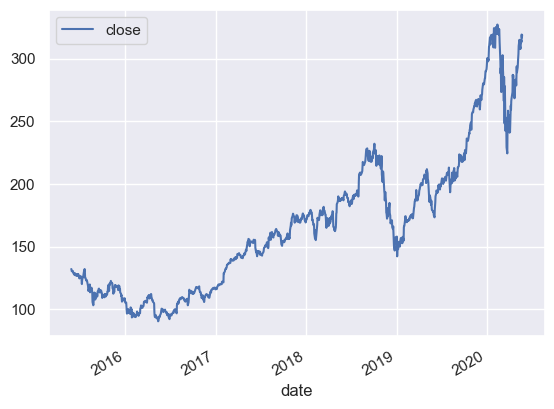

In [19]:
ds.plot()
#somewhat upward trend

## Decomposition method to check all three components in the dataset:
### -- trend, seasonality, noise

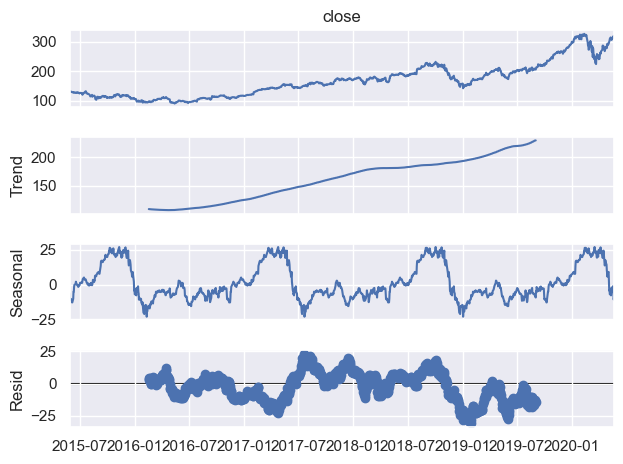

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose
decompose = seasonal_decompose(ds['close'], period = 365)
decompose.plot()
plt.show()

## Check Auto-Correlation using Durbin-Watson Test

In [21]:
import statsmodels.api as sm
sm.stats.durbin_watson(ds)

array([0.00042847])

In [22]:
# HIGHLY POSITIVE AUTO-CORRELATION FOUND!!

### CHECKING WHETHER DATA IS STATIONARY OR NOT USING AUGMENTED DICKEY FULLER TEST METHOD

In [23]:
from statsmodels.tsa.stattools import adfuller

In [24]:
def adf_check(timeseries):
    result = adfuller(timeseries)
    print('Augmented Dickey Fuller Test- Check whether data is stationary or non-stationary')
    print('---------------------------------------------------------------------------------')
    labels = ['ADF Test Statistic', 'p-value', '#Lags used', 'Number of observations used']

    for a, b in zip(result, labels):
        print(b + ' : ' +str(a))
        print('-----------')

    if result[1] <= 0.05:
        print('Strong evidence against Null hypothesis and my time series is Stationary.')
    else:
        print('Weak evidence against Null hypothesis and my time series is Non-stationary.')

adf_check(ds['close'])

Augmented Dickey Fuller Test- Check whether data is stationary or non-stationary
---------------------------------------------------------------------------------
ADF Test Statistic : -0.10012966467734916
-----------
p-value : 0.9494256168598441
-----------
#Lags used : 18
-----------
Number of observations used : 1239
-----------
Weak evidence against Null hypothesis and my time series is Non-stationary.


## Making data stationary using Lag Function !!

In [25]:
ds['1st diff'] = ds['close'] - ds['close'].shift(1)
ds

,close,1st diff
date,,
2015-05-27,132.045,NaN
2015-05-28,131.780,-0.265
2015-05-29,130.280,-1.500
2015-06-01,130.535,0.255
2015-06-02,129.960,-0.575
...,...,...
2020-05-18,314.960,7.250
2020-05-19,313.140,-1.820
2020-05-20,319.230,6.090


In [26]:
# Checking again whether data is stationary or non-stationary
adf_check(ds['1st diff'].dropna())

Augmented Dickey Fuller Test- Check whether data is stationary or non-stationary
---------------------------------------------------------------------------------
ADF Test Statistic : -6.239529846021893
-----------
p-value : 4.734448928660651e-08
-----------
#Lags used : 17
-----------
Number of observations used : 1239
-----------
Strong evidence against Null hypothesis and my time series is Stationary.


### data is now stationary, therefore we get d = 1.

## To find D for Seasonality,
### our seasonality period is 30 days, therefore you compare the first month data with the second, the second month with the third and so on..

In [27]:
# Checking if Seasonality data is Stationary or not:
ds['30d diff'] = ds['close'] - ds['close'].shift(30)
ds.head(50)

,close,1st diff,30d diff
date,,,
2015-05-27,132.045,NaN,NaN
2015-05-28,131.780,-0.265,NaN
2015-05-29,130.280,-1.500,NaN
2015-06-01,130.535,0.255,NaN
2015-06-02,129.960,-0.575,NaN
2015-06-03,130.120,0.160,NaN
2015-06-04,129.360,-0.760,NaN
2015-06-05,128.650,-0.710,NaN
2015-06-08,127.800,-0.850,NaN


In [28]:
adf_check(ds['30d diff'].dropna())

Augmented Dickey Fuller Test- Check whether data is stationary or non-stationary
---------------------------------------------------------------------------------
ADF Test Statistic : -7.144467547383239
-----------
p-value : 3.25981570523404e-10
-----------
#Lags used : 22
-----------
Number of observations used : 1205
-----------
Strong evidence against Null hypothesis and my time series is Stationary.


## Both Trend and Seasonality are STATIONARY !!
### Trend, d = 1.
### Seasonality, D = 1.

### For p, q, P and Q: we will check Partial Auto-Correlation and Auto-Correlation using visualization method.

In [29]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

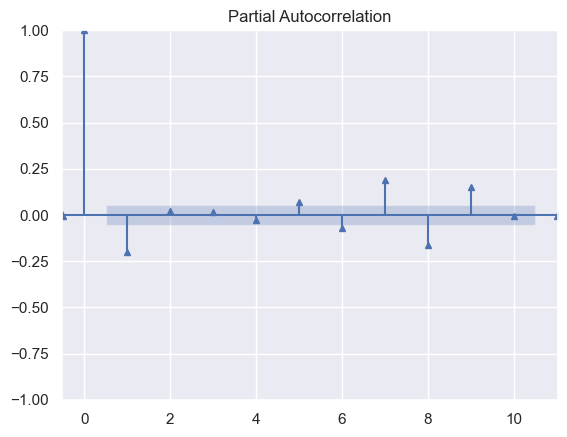

In [30]:
# First target: Trend
# p = partial auto-correlation = ?
# q = auto-correlation = ?
# d = difference = 1

plot_pacf(ds['1st diff'].dropna(), lags = 10, marker = '^')
plt.show()

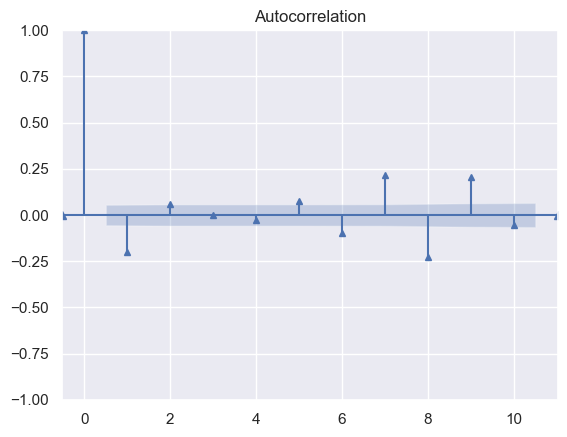

In [31]:
plot_acf(ds['1st diff'].dropna(), lags = 10, marker = '^')
plt.show()


## First target: Trend
## p = partial auto-correlation = 1
## q = auto-correlation = 2
## d = difference = 1

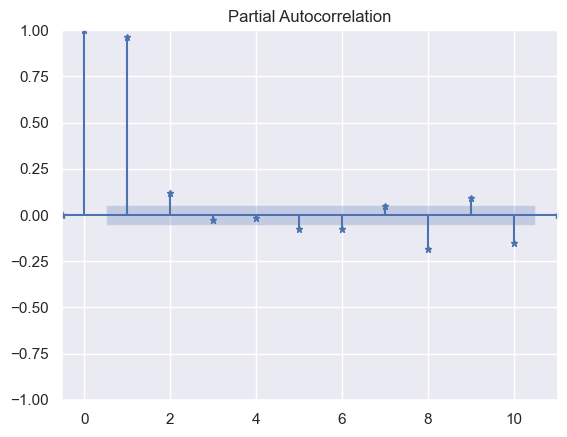

In [32]:
# Second Target : trend
# P = partial auto-correlation = ?
# Q = auto-correlation = ?
# D = difference = 1

plot_pacf(ds['30d diff'].dropna(), lags = 10, marker = '*')
plt.show()

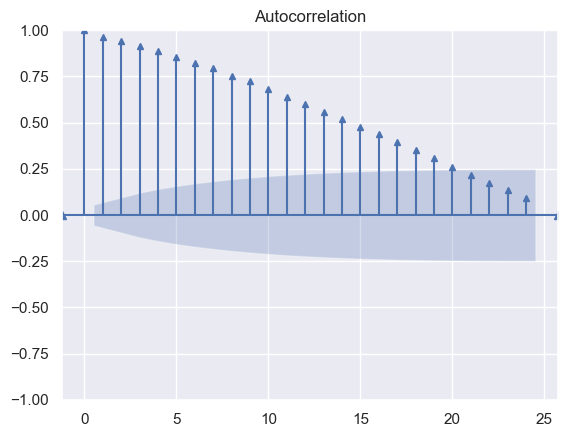

In [33]:
plot_acf(ds['30d diff'].dropna(), lags = 24, marker = '^')
plt.show()

## Second target: Seasonality
## P = partial auto-correlation = 2
## Q = auto-correlation = 20
## D = difference = 1



## USING FACEBOOK PROPHET MODEL

In [34]:
!pip install pystan

  Obtaining dependency information for pystan from https://files.pythonhosted.org/packages/3f/7f/657d722f81035931513a9760751a215f09fb1474c15c043b5a5ed17e61ca/pystan-3.10.0-py3-none-any.whl.metadata
  Using cached pystan-3.10.0-py3-none-any.whl.metadata (3.7 kB)
  Obtaining dependency information for clikit<0.7,>=0.6 from https://files.pythonhosted.org/packages/f2/3d/4394c710b9195b83382dc67bdd1040e5ebfc3fc8df90e20fe74341298c57/clikit-0.6.2-py2.py3-none-any.whl.metadata
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Obtaining dependency information for pystan from https://files.pythonhosted.org/packages/20/e7/726e923d328524d0151080f5a1d20f57a025b6d2f72a252c2d2d7abe57f9/pystan-3.9.1-py3-none-any.whl.metadata
  Using cached pystan-3.9.1-py3-none-any.whl.metadata (3.7 kB)
  Obtaining dependency information for pystan from https:

  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [6 lines of output]
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 34, in <module>
    File "C:\Users\HP\AppData\Local\Temp\pip-install-4zxospa1\pystan_6fbca9832f1448fdb41c07ee37ecdcbc\setup.py", line 122, in <module>
      from Cython.Build.Inline import _get_build_extension
  ModuleNotFoundError: No module named 'Cython'
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

Encountered error while generating package metadata.

See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [35]:
!python -m pip install prophet

In [36]:
import prophet

In [37]:
df = df[['date', 'close']]

In [38]:
# FACEBOOK PROPHET MODEL
df_prophet = df.rename(columns = {'date': 'ds', 'close': 'y'})
df_prophet.head()

,ds,y
0,2015-05-27,132.045
1,2015-05-28,131.780
2,2015-05-29,130.280
3,2015-06-01,130.535
4,2015-06-02,129.960


In [39]:
from prophet import Prophet

In [40]:
m = Prophet()
model = m.fit(df_prophet)

11:03:07 - cmdstanpy - INFO - Chain [1] start processing
11:03:08 - cmdstanpy - INFO - Chain [1] done processing


In [41]:
model.seasonalities

OrderedDict([('yearly',
              {'period': 365.25,
               'fourier_order': 10,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None}),
             ('weekly',
              {'period': 7,
               'fourier_order': 3,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None})])

In [42]:
#Build Time Series Forecasting Model
future_price = model.make_future_dataframe(periods = 365, freq = 'D')
future_price

,ds
0,2015-05-27
1,2015-05-28
2,2015-05-29
3,2015-06-01
4,2015-06-02
...,...
1618,2021-05-18
1619,2021-05-19
1620,2021-05-20
1621,2021-05-21


In [43]:
df_prophet.shape

(1258, 2)

In [44]:
future_price.shape

(1623, 1)

In [45]:
prediction = model.predict(future_price)
prediction

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-05-27,132.383157,114.244093,146.200754,132.383157,132.383157,-2.197372,-2.197372,-2.197372,0.629502,0.629502,0.629502,-2.826873,-2.826873,-2.826873,0.0,0.0,0.0,130.185785
1,2015-05-28,132.239519,113.424156,145.190064,132.239519,132.239519,-2.528267,-2.528267,-2.528267,0.528054,0.528054,0.528054,-3.056322,-3.056322,-3.056322,0.0,0.0,0.0,129.711251
2,2015-05-29,132.095881,114.176966,144.331578,132.095881,132.095881,-3.057380,-3.057380,-3.057380,0.227765,0.227765,0.227765,-3.285145,-3.285145,-3.285145,0.0,0.0,0.0,129.038501
3,2015-06-01,131.664967,113.153851,143.721986,131.664967,131.664967,-3.871965,-3.871965,-3.871965,0.071562,0.071562,0.071562,-3.943528,-3.943528,-3.943528,0.0,0.0,0.0,127.793002
4,2015-06-02,131.521329,112.092698,141.830078,131.521329,131.521329,-3.668058,-3.668058,-3.668058,0.478972,0.478972,0.478972,-4.147030,-4.147030,-4.147030,0.0,0.0,0.0,127.853271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618,2021-05-18,419.298412,362.493600,472.901710,365.315954,471.080209,-0.774267,-0.774267,-0.774267,0.478972,0.478972,0.478972,-1.253239,-1.253239,-1.253239,0.0,0.0,0.0,418.524145
1619,2021-05-19,419.605406,361.214388,472.034898,365.406666,471.545835,-0.745290,-0.745290,-0.745290,0.629502,0.629502,0.629502,-1.374791,-1.374791,-1.374791,0.0,0.0,0.0,418.860116
1620,2021-05-20,419.912400,363.867615,474.759024,365.497378,472.011461,-0.990283,-0.990283,-0.990283,0.528054,0.528054,0.528054,-1.518337,-1.518337,-1.518337,0.0,0.0,0.0,418.922117
1621,2021-05-21,420.219394,361.894877,471.191866,365.588090,472.484150,-1.454187,-1.454187,-1.454187,0.227765,0.227765,0.227765,-1.681952,-1.681952,-1.681952,0.0,0.0,0.0,418.765207


In [46]:
prediction.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [47]:
prediction[['ds', 'yhat_lower', 'yhat_upper','yhat']].tail(20)

,ds,yhat_lower,yhat_upper,yhat
1603,2021-05-03,360.775193,463.845848,412.808204
1604,2021-05-04,361.520841,463.901414,413.651612
1605,2021-05-05,361.250385,466.698533,414.238842
1606,2021-05-06,361.619128,465.625763,414.571629
1607,2021-05-07,361.327813,462.231523,414.699846
1608,2021-05-08,359.055192,467.999912,413.923674
1609,2021-05-09,362.487487,464.976745,414.331048
1610,2021-05-10,362.528763,468.166798,415.762788
1611,2021-05-11,361.687104,468.835568,416.544616
1612,2021-05-12,360.540258,468.253726,417.049369


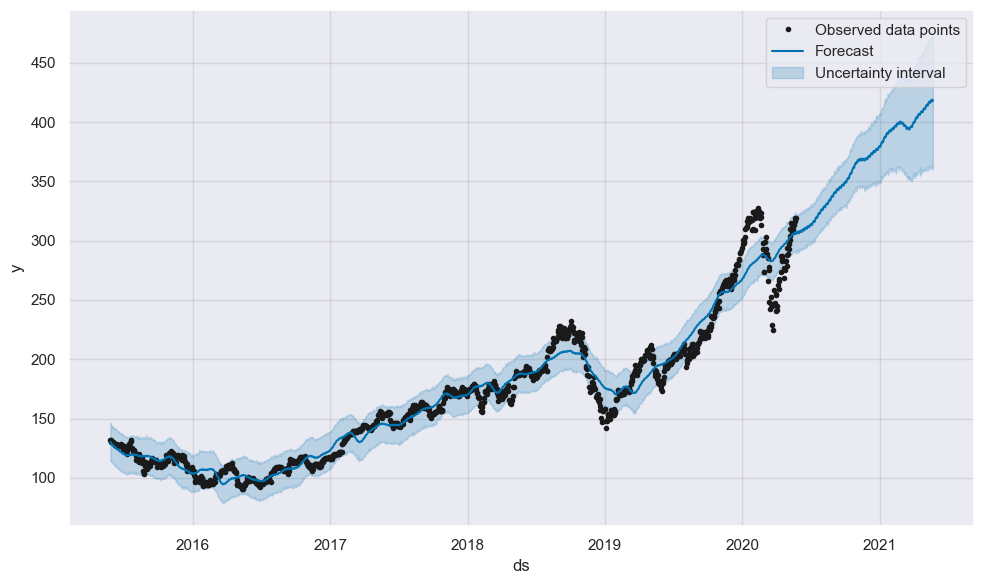

In [48]:
model.plot(prediction, include_legend = True)
plt.show()

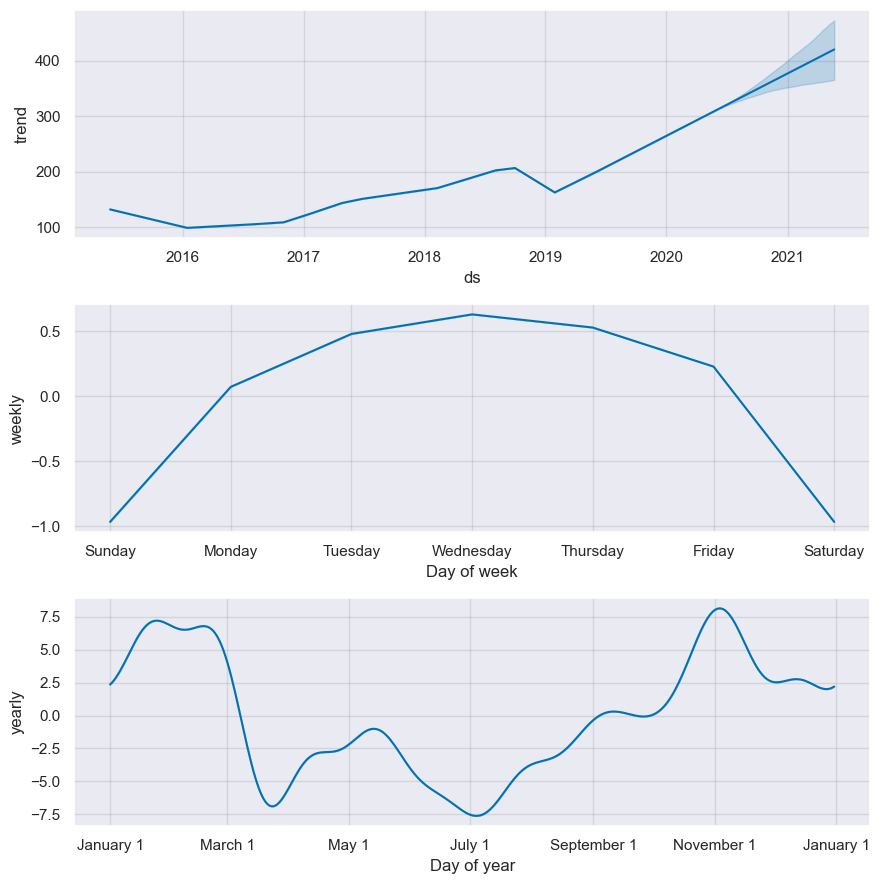

In [49]:
model.plot_components(prediction)
plt.show()

In [50]:
# cross validation
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, horizon = '100 days', period = '50 days', initial = '300 days')

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/29 [00:00<?, ?it/s]

11:03:11 - cmdstanpy - INFO - Chain [1] start processing
11:03:11 - cmdstanpy - INFO - Chain [1] done processing
11:03:11 - cmdstanpy - INFO - Chain [1] start processing
11:03:11 - cmdstanpy - INFO - Chain [1] done processing
11:03:12 - cmdstanpy - INFO - Chain [1] start processing
11:03:12 - cmdstanpy - INFO - Chain [1] done processing
11:03:12 - cmdstanpy - INFO - Chain [1] start processing
11:03:12 - cmdstanpy - INFO - Chain [1] done processing
11:03:12 - cmdstanpy - INFO - Chain [1] start processing
11:03:12 - cmdstanpy - INFO - Chain [1] done processing
11:03:13 - cmdstanpy - INFO - Chain [1] start processing
11:03:13 - cmdstanpy - INFO - Chain [1] done processing
11:03:13 - cmdstanpy - INFO - Chain [1] start processing
11:03:13 - cmdstanpy - INFO - Chain [1] done processing
11:03:13 - cmdstanpy - INFO - Chain [1] start processing
11:03:14 - cmdstanpy - INFO - Chain [1] done processing
11:03:14 - cmdstanpy - INFO - Chain [1] start processing
11:03:14 - cmdstanpy - INFO - Chain [1]

In [51]:
from prophet.diagnostics import performance_metrics
df_performance = performance_metrics(df_cv)
df_performance

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,10 days,272.699942,16.513629,11.860714,0.067165,0.047425,0.066212,0.315000
1,11 days,281.749838,16.785405,12.208058,0.069101,0.053172,0.068389,0.305000
2,12 days,273.196623,16.528661,12.101032,0.068898,0.058111,0.068414,0.330952
3,13 days,286.085504,16.914062,12.452456,0.070626,0.062145,0.070271,0.341316
4,14 days,310.452086,17.619651,13.139562,0.074415,0.065134,0.073939,0.336500
...,...,...,...,...,...,...,...,...
86,96 days,1569.878551,39.621693,30.384655,0.160528,0.130034,0.163108,0.135750
87,97 days,1452.847704,38.116239,29.291473,0.154738,0.130034,0.157783,0.145000
88,98 days,1398.767362,37.400098,28.753948,0.150970,0.130034,0.153953,0.159737
89,99 days,1482.693984,38.505766,29.602534,0.154536,0.139694,0.157094,0.167143


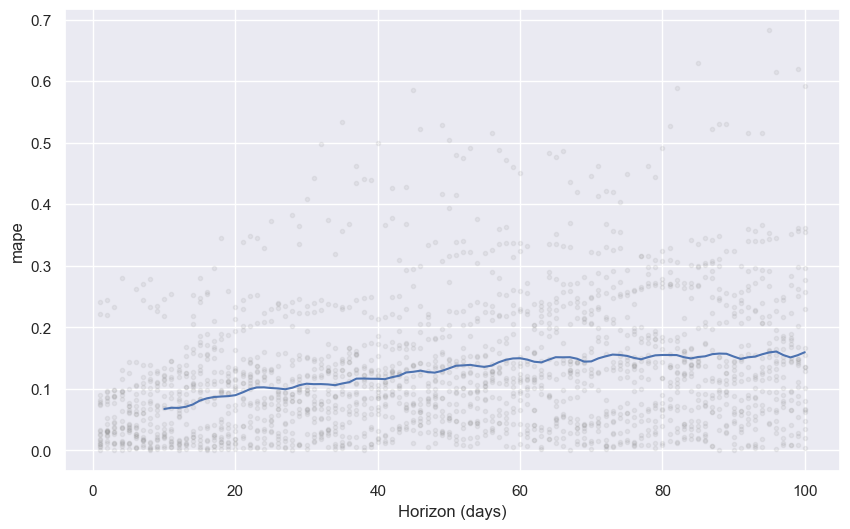

In [52]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric = 'mape')

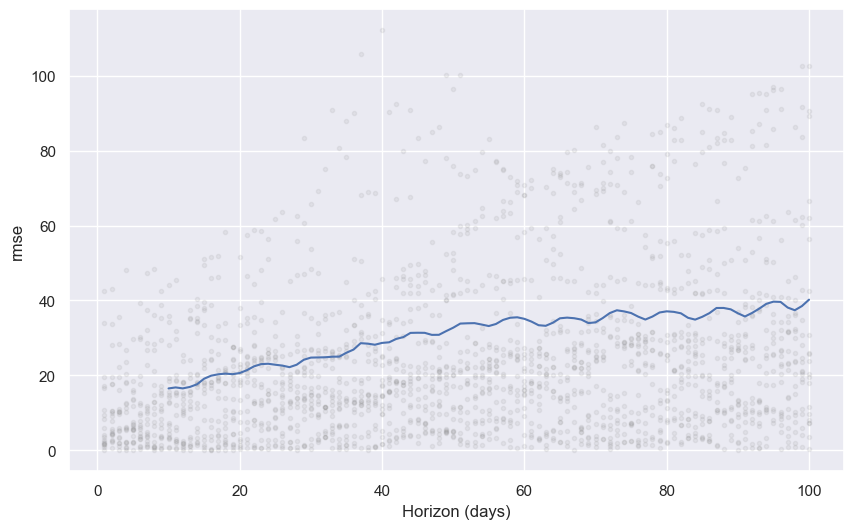

In [53]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric = 'rmse')

In [54]:
df_prophet

,ds,y
0,2015-05-27,132.045
1,2015-05-28,131.780
2,2015-05-29,130.280
3,2015-06-01,130.535
4,2015-06-02,129.960
...,...,...
1253,2020-05-18,314.960
1254,2020-05-19,313.140
1255,2020-05-20,319.230
1256,2020-05-21,316.850


In [55]:
prediction

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-05-27,132.383157,114.244093,146.200754,132.383157,132.383157,-2.197372,-2.197372,-2.197372,0.629502,0.629502,0.629502,-2.826873,-2.826873,-2.826873,0.0,0.0,0.0,130.185785
1,2015-05-28,132.239519,113.424156,145.190064,132.239519,132.239519,-2.528267,-2.528267,-2.528267,0.528054,0.528054,0.528054,-3.056322,-3.056322,-3.056322,0.0,0.0,0.0,129.711251
2,2015-05-29,132.095881,114.176966,144.331578,132.095881,132.095881,-3.057380,-3.057380,-3.057380,0.227765,0.227765,0.227765,-3.285145,-3.285145,-3.285145,0.0,0.0,0.0,129.038501
3,2015-06-01,131.664967,113.153851,143.721986,131.664967,131.664967,-3.871965,-3.871965,-3.871965,0.071562,0.071562,0.071562,-3.943528,-3.943528,-3.943528,0.0,0.0,0.0,127.793002
4,2015-06-02,131.521329,112.092698,141.830078,131.521329,131.521329,-3.668058,-3.668058,-3.668058,0.478972,0.478972,0.478972,-4.147030,-4.147030,-4.147030,0.0,0.0,0.0,127.853271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618,2021-05-18,419.298412,362.493600,472.901710,365.315954,471.080209,-0.774267,-0.774267,-0.774267,0.478972,0.478972,0.478972,-1.253239,-1.253239,-1.253239,0.0,0.0,0.0,418.524145
1619,2021-05-19,419.605406,361.214388,472.034898,365.406666,471.545835,-0.745290,-0.745290,-0.745290,0.629502,0.629502,0.629502,-1.374791,-1.374791,-1.374791,0.0,0.0,0.0,418.860116
1620,2021-05-20,419.912400,363.867615,474.759024,365.497378,472.011461,-0.990283,-0.990283,-0.990283,0.528054,0.528054,0.528054,-1.518337,-1.518337,-1.518337,0.0,0.0,0.0,418.922117
1621,2021-05-21,420.219394,361.894877,471.191866,365.588090,472.484150,-1.454187,-1.454187,-1.454187,0.227765,0.227765,0.227765,-1.681952,-1.681952,-1.681952,0.0,0.0,0.0,418.765207


In [57]:
import itertools

# Hyper-tunng Prophet Model parameters


In [62]:
param_grid = {
     'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
     'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
 }

all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []

for params in all_params:
     m = Prophet(**params).fit(df_prophet)
     df_cv = cross_validation(m, horizon='100 days', period='50 days', initial='365.25 days', parallel="processes")
     df_p = performance_metrics(df_cv, rolling_window=1)
     rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
print(tuning_results)
best_params = all_params[np.argmin(rmses)]
print(best_params)

11:21:51 - cmdstanpy - INFO - Chain [1] start processing
11:21:51 - cmdstanpy - INFO - Chain [1] done processing
11:22:05 - cmdstanpy - INFO - Chain [1] start processing
11:22:05 - cmdstanpy - INFO - Chain [1] done processing
11:22:19 - cmdstanpy - INFO - Chain [1] start processing
11:22:19 - cmdstanpy - INFO - Chain [1] done processing
11:22:32 - cmdstanpy - INFO - Chain [1] start processing
11:22:32 - cmdstanpy - INFO - Chain [1] done processing
11:22:46 - cmdstanpy - INFO - Chain [1] start processing
11:22:46 - cmdstanpy - INFO - Chain [1] done processing
11:22:56 - cmdstanpy - INFO - Chain [1] start processing
11:22:56 - cmdstanpy - INFO - Chain [1] done processing
11:23:07 - cmdstanpy - INFO - Chain [1] start processing
11:23:07 - cmdstanpy - INFO - Chain [1] done processing
11:23:17 - cmdstanpy - INFO - Chain [1] start processing
11:23:17 - cmdstanpy - INFO - Chain [1] done processing
11:23:27 - cmdstanpy - INFO - Chain [1] start processing
11:23:28 - cmdstanpy - INFO - Chain [1]

    changepoint_prior_scale  seasonality_prior_scale       rmse
0                     0.001                     0.01  36.037790
1                     0.001                     0.10  36.713249
2                     0.001                     1.00  36.706222
3                     0.001                    10.00  36.711500
4                     0.010                     0.01  32.045252
5                     0.010                     0.10  32.426174
6                     0.010                     1.00  32.392604
7                     0.010                    10.00  32.437195
8                     0.100                     0.01  30.823399
9                     0.100                     0.10  33.351465
10                    0.100                     1.00  33.351888
11                    0.100                    10.00  33.314962
12                    0.500                     0.01  30.140930
13                    0.500                     0.10  34.410503
14                    0.500             

In [63]:
m = Prophet(**best_params)
model = m.fit(df_prophet)

11:30:33 - cmdstanpy - INFO - Chain [1] start processing
11:30:34 - cmdstanpy - INFO - Chain [1] done processing


In [64]:
model.seasonalities

OrderedDict([('yearly',
              {'period': 365.25,
               'fourier_order': 10,
               'prior_scale': 0.01,
               'mode': 'additive',
               'condition_name': None}),
             ('weekly',
              {'period': 7,
               'fourier_order': 3,
               'prior_scale': 0.01,
               'mode': 'additive',
               'condition_name': None})])

In [65]:
#Build Time Series Forecasting Model
future_price = model.make_future_dataframe(periods = 365, freq = 'D')
future_price

,ds
0,2015-05-27
1,2015-05-28
2,2015-05-29
3,2015-06-01
4,2015-06-02
...,...
1618,2021-05-18
1619,2021-05-19
1620,2021-05-20
1621,2021-05-21


In [66]:
df_prophet.shape

(1258, 2)

In [67]:
future_price.shape

(1623, 1)

In [68]:
prediction = model.predict(future_price)
prediction

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-05-27,145.820279,124.676842,146.866626,145.820279,145.820279,-9.982890,-9.982890,-9.982890,0.360747,0.360747,0.360747,-10.343637,-10.343637,-10.343637,0.0,0.0,0.0,135.837389
1,2015-05-28,145.711868,125.136722,145.216415,145.711868,145.711868,-10.678666,-10.678666,-10.678666,0.138849,0.138849,0.138849,-10.817515,-10.817515,-10.817515,0.0,0.0,0.0,135.033202
2,2015-05-29,145.603457,124.005601,143.448728,145.603457,145.603457,-11.445482,-11.445482,-11.445482,-0.153798,-0.153798,-0.153798,-11.291683,-11.291683,-11.291683,0.0,0.0,0.0,134.157975
3,2015-06-01,145.278223,122.144308,142.128446,145.278223,145.278223,-13.029754,-13.029754,-13.029754,-0.365012,-0.365012,-0.365012,-12.664742,-12.664742,-12.664742,0.0,0.0,0.0,132.248469
4,2015-06-02,145.169811,121.511784,141.526646,145.169811,145.169811,-13.055257,-13.055257,-13.055257,0.035476,0.035476,0.035476,-13.090733,-13.090733,-13.090733,0.0,0.0,0.0,132.114554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618,2021-05-18,400.921396,24.695833,821.041117,35.762091,832.993374,-7.028100,-7.028100,-7.028100,0.035476,0.035476,0.035476,-7.063575,-7.063575,-7.063575,0.0,0.0,0.0,393.893296
1619,2021-05-19,401.195360,24.399376,829.436483,34.455567,834.802904,-6.970930,-6.970930,-6.970930,0.360747,0.360747,0.360747,-7.331677,-7.331677,-7.331677,0.0,0.0,0.0,394.224430
1620,2021-05-20,401.469325,26.264295,826.620394,32.861083,836.550984,-7.500271,-7.500271,-7.500271,0.138849,0.138849,0.138849,-7.639120,-7.639120,-7.639120,0.0,0.0,0.0,393.969053
1621,2021-05-21,401.743289,21.485652,828.758641,31.451868,838.284721,-8.136879,-8.136879,-8.136879,-0.153798,-0.153798,-0.153798,-7.983080,-7.983080,-7.983080,0.0,0.0,0.0,393.606411


In [69]:
prediction.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [70]:
prediction[['ds', 'yhat_lower', 'yhat_upper','yhat']].tail(20)

,ds,yhat_lower,yhat_upper,yhat
1603,2021-05-03,51.955299,798.698582,389.105230
1604,2021-05-04,47.442155,804.686971,389.938740
1605,2021-05-05,48.675085,809.613232,390.696377
1606,2021-05-06,48.710594,807.919208,390.901453
1607,2021-05-07,46.459709,808.381445,391.025453
1608,2021-05-08,47.890028,811.205317,391.596844
1609,2021-05-09,41.377810,812.420608,391.929125
1610,2021-05-10,37.165652,803.104297,391.952739
1611,2021-05-11,34.584248,815.901631,392.679950
1612,2021-05-12,32.451755,817.529930,393.298621


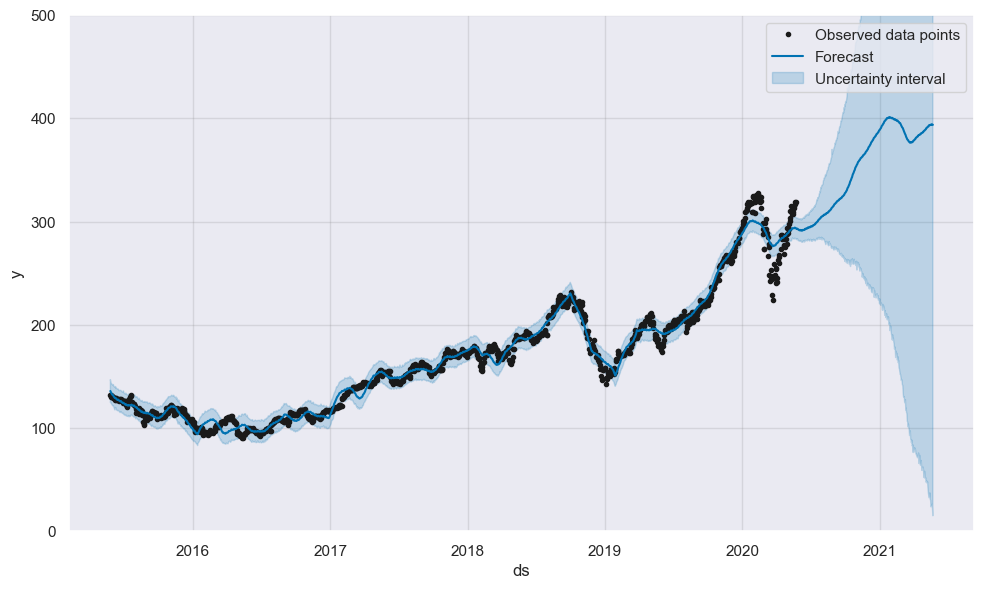

In [73]:
fig = model.plot(prediction, include_legend = True)
ax = fig.gca()
ax.set_ylim([0, 500])
plt.show()

# we can see better accuracy in model performance now.

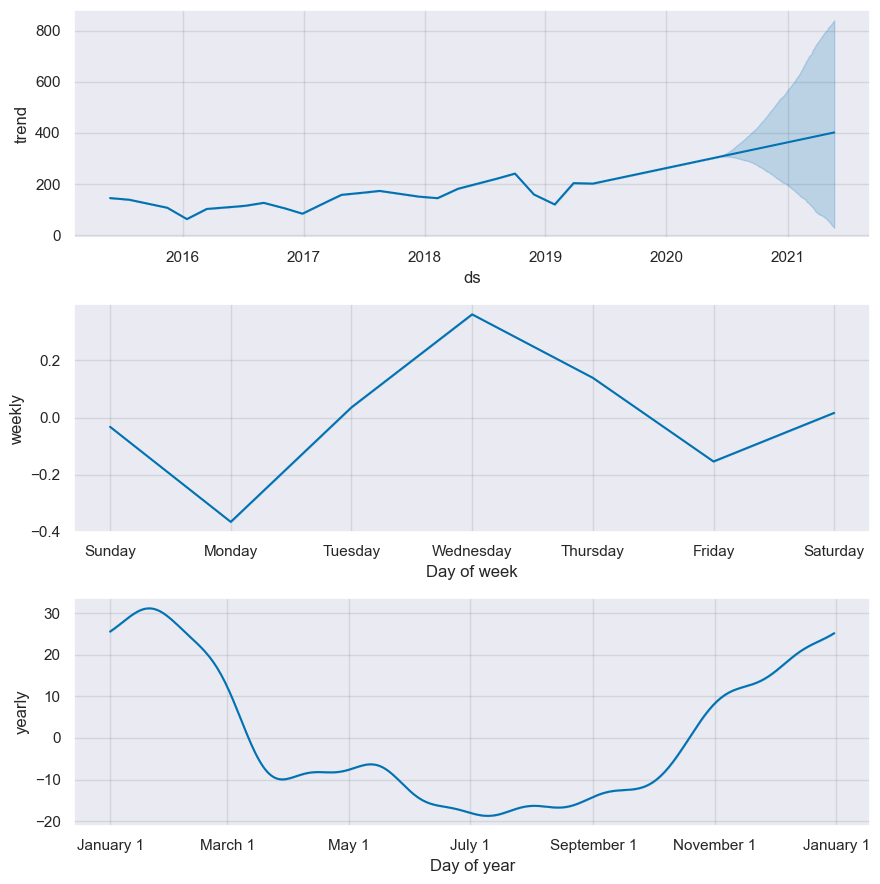

In [74]:
model.plot_components(prediction)
plt.show()

In [79]:
# cross validation
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, horizon = '100 days', period = '50 days', initial = '365.25 days')

  0%|          | 0/28 [00:00<?, ?it/s]

11:32:01 - cmdstanpy - INFO - Chain [1] start processing
11:32:01 - cmdstanpy - INFO - Chain [1] done processing
11:32:01 - cmdstanpy - INFO - Chain [1] start processing
11:32:01 - cmdstanpy - INFO - Chain [1] done processing
11:32:02 - cmdstanpy - INFO - Chain [1] start processing
11:32:02 - cmdstanpy - INFO - Chain [1] done processing
11:32:02 - cmdstanpy - INFO - Chain [1] start processing
11:32:02 - cmdstanpy - INFO - Chain [1] done processing
11:32:02 - cmdstanpy - INFO - Chain [1] start processing
11:32:03 - cmdstanpy - INFO - Chain [1] done processing
11:32:03 - cmdstanpy - INFO - Chain [1] start processing
11:32:04 - cmdstanpy - INFO - Chain [1] done processing
11:32:04 - cmdstanpy - INFO - Chain [1] start processing
11:32:04 - cmdstanpy - INFO - Chain [1] done processing
11:32:05 - cmdstanpy - INFO - Chain [1] start processing
11:32:05 - cmdstanpy - INFO - Chain [1] done processing
11:32:06 - cmdstanpy - INFO - Chain [1] start processing
11:32:06 - cmdstanpy - INFO - Chain [1]

In [80]:
from prophet.diagnostics import performance_metrics
df_performance = performance_metrics(df_cv)
df_performance

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,10 days,92.334814,9.609101,7.468032,0.041057,0.035479,0.041115,0.284974
1,11 days,97.680229,9.883331,7.773690,0.042742,0.037732,0.042864,0.272539
2,12 days,108.601935,10.421225,8.130512,0.044741,0.040228,0.044898,0.259067
3,13 days,134.135546,11.581690,8.834107,0.048251,0.045993,0.048325,0.250068
4,14 days,152.782893,12.360538,9.366149,0.050489,0.048651,0.050533,0.246114
...,...,...,...,...,...,...,...,...
86,96 days,1699.820294,41.228877,29.004355,0.146543,0.123832,0.147997,0.782383
87,97 days,1592.995187,39.912344,28.322128,0.143250,0.125780,0.144941,0.797927
88,98 days,1549.899683,39.368765,28.446308,0.143352,0.128769,0.144926,0.808290
89,99 days,1631.779747,40.395294,29.226379,0.146381,0.128769,0.147578,0.810363


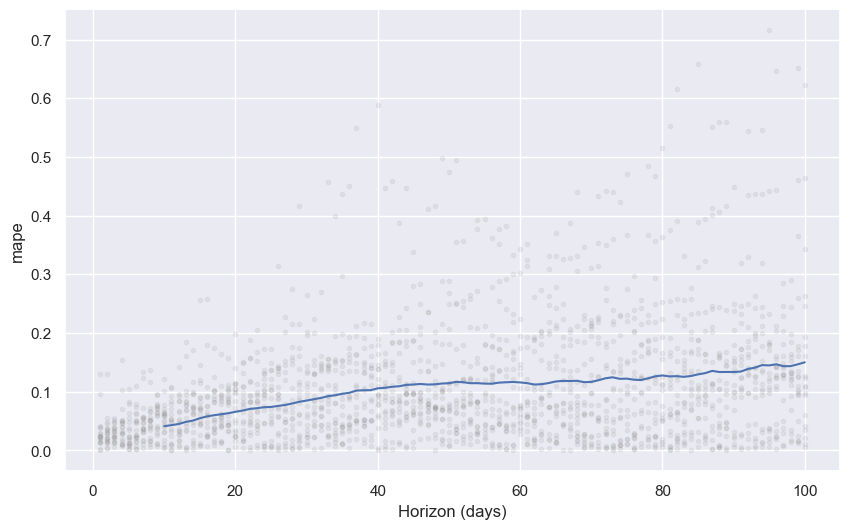

In [81]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric = 'mape')

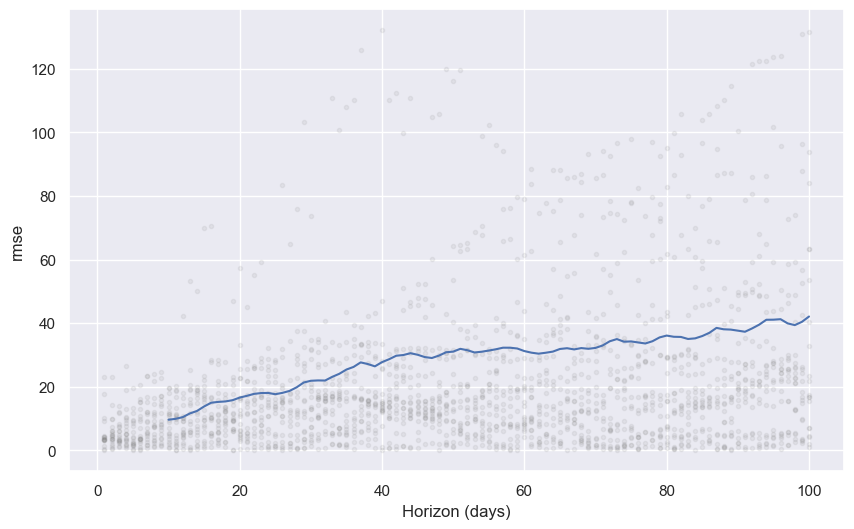

In [82]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric = 'rmse')

In [83]:
df_prophet

,ds,y
0,2015-05-27,132.045
1,2015-05-28,131.780
2,2015-05-29,130.280
3,2015-06-01,130.535
4,2015-06-02,129.960
...,...,...
1253,2020-05-18,314.960
1254,2020-05-19,313.140
1255,2020-05-20,319.230
1256,2020-05-21,316.850


In [84]:
prediction

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-05-27,145.820279,124.676842,146.866626,145.820279,145.820279,-9.982890,-9.982890,-9.982890,0.360747,0.360747,0.360747,-10.343637,-10.343637,-10.343637,0.0,0.0,0.0,135.837389
1,2015-05-28,145.711868,125.136722,145.216415,145.711868,145.711868,-10.678666,-10.678666,-10.678666,0.138849,0.138849,0.138849,-10.817515,-10.817515,-10.817515,0.0,0.0,0.0,135.033202
2,2015-05-29,145.603457,124.005601,143.448728,145.603457,145.603457,-11.445482,-11.445482,-11.445482,-0.153798,-0.153798,-0.153798,-11.291683,-11.291683,-11.291683,0.0,0.0,0.0,134.157975
3,2015-06-01,145.278223,122.144308,142.128446,145.278223,145.278223,-13.029754,-13.029754,-13.029754,-0.365012,-0.365012,-0.365012,-12.664742,-12.664742,-12.664742,0.0,0.0,0.0,132.248469
4,2015-06-02,145.169811,121.511784,141.526646,145.169811,145.169811,-13.055257,-13.055257,-13.055257,0.035476,0.035476,0.035476,-13.090733,-13.090733,-13.090733,0.0,0.0,0.0,132.114554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618,2021-05-18,400.921396,24.695833,821.041117,35.762091,832.993374,-7.028100,-7.028100,-7.028100,0.035476,0.035476,0.035476,-7.063575,-7.063575,-7.063575,0.0,0.0,0.0,393.893296
1619,2021-05-19,401.195360,24.399376,829.436483,34.455567,834.802904,-6.970930,-6.970930,-6.970930,0.360747,0.360747,0.360747,-7.331677,-7.331677,-7.331677,0.0,0.0,0.0,394.224430
1620,2021-05-20,401.469325,26.264295,826.620394,32.861083,836.550984,-7.500271,-7.500271,-7.500271,0.138849,0.138849,0.138849,-7.639120,-7.639120,-7.639120,0.0,0.0,0.0,393.969053
1621,2021-05-21,401.743289,21.485652,828.758641,31.451868,838.284721,-8.136879,-8.136879,-8.136879,-0.153798,-0.153798,-0.153798,-7.983080,-7.983080,-7.983080,0.0,0.0,0.0,393.606411
